In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import os

dataset_dir = kagglehub.dataset_download('blastchar/telco-customer-churn')

print(f"Downloaded dataset directory: {dataset_dir}")
print(f"Contents of the directory: {os.listdir(dataset_dir)}")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Downloaded dataset directory: /kaggle/input/telco-customer-churn
Contents of the directory: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


Cleaning the Data


1. TotalCharges has a Dtype of object (string). However, it represents money, so it should be a float64 just like MonthlyCharges.

   The Fix: You need to force this column into a numeric format and coerce the errors into true null values so you can handle them.

2. Remove the Noise: customerID Your df.info() shows customerID. While useful for a business, a completely unique, randomized string has zero predictive power for a machine learning model. If you leave it in, it will confuse your classification algorithms.
 The Fix: Drop the column entirely.

 3. Handle the Target Variable: ChurnCurrently, your Churn column is an object (likely "Yes" and "No"). To evaluate this using statistical techniques or Scikit-learn models, it needs to be binary.The Fix: Map it to $1$ and $0$.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Shape after cleaning: {df.shape}")
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

Shape after cleaning: (7032, 20)
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80
Churn,7032.0,0.265785,0.441782,0.00,0.0000,0.000,1.0000,1.00


Statistical Analysis

How to Interpret Your Results

When you run this code, focus entirely on the p-value. In statistics, we typically use an alpha level (alpha) of 0.05.

1. If p < 0.05: The feature is statistically significant. There is a meaningful relationship between this feature and whether a customer churns. You absolutely want this in your machine learning model.

2. If p >= 0.05: The feature is likely just noise. For example, you might find that gender has a high $p$-value, meaning men and women churn at roughly the exact same rate. Feeding this to a machine learning model will only confuse it.

1. T-Tests for Continuous Variables
An Independent T-test compares the averages of a continuous variable between two groups (Churned vs. Retained) to see if the difference is statistically significant.

We will test tenure, MonthlyCharges, and TotalCharges

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Define your continuous columns
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("--- T-Test Results (Continuous Features) ---")
for col in continuous_cols:
    # Group the data by Churn status
    churned = df[df['Churn'] == 1][col].dropna()
    retained = df[df['Churn'] == 0][col].dropna()

    # Run the independent T-test
    t_stat, p_val = ttest_ind(churned, retained, equal_var=False)

    # Print the results
    print(f"{col}:")
    print(f"  - Mean (Churned) : {churned.mean():.2f}")
    print(f"  - Mean (Retained): {retained.mean():.2f}")
    print(f"  - p-value        : {p_val:.4e}")

    if p_val < 0.05:
        print("  -> Statistically Significant: KEEP this feature.\n")
    else:
        print("  -> Not Significant: Consider dropping this feature.\n")

--- T-Test Results (Continuous Features) ---
tenure:
  - Mean (Churned) : 17.98
  - Mean (Retained): 37.65
  - p-value        : 2.3471e-234
  -> Statistically Significant: KEEP this feature.

MonthlyCharges:
  - Mean (Churned) : 74.44
  - Mean (Retained): 61.31
  - p-value        : 2.6574e-72
  -> Statistically Significant: KEEP this feature.

TotalCharges:
  - Mean (Churned) : 1531.80
  - Mean (Retained): 2555.34
  - p-value        : 1.1525e-75
  -> Statistically Significant: KEEP this feature.



2. Chi-Square Tests for Categorical Variables
The Chi-Square test evaluates whether two categorical variables are related. We will loop through all your categorical columns (like Contract, InternetService, PaymentMethod) and test them against the Churn column.

In [ ]:
from scipy.stats import chi2_contingency

# Get all categorical columns (excluding the target 'Churn' and any remaining IDs)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in categorical_cols: categorical_cols.remove('customerID')
if 'Churn' in categorical_cols: categorical_cols.remove('Churn')

print("--- Chi-Square Results (Categorical Features) ---")
for col in categorical_cols:
    # Create a contingency table (cross-tabulation)
    contingency_table = pd.crosstab(df[col], df['Churn'])

    # Run the Chi-Square test
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)

    print(f"{col}: p-value = {p_val:.4e}")

    if p_val < 0.05:
        print("  -> Statistically Significant: KEEP this feature.")
    else:
        print("  -> Not Significant: Consider dropping this feature.")
    print("-" * 30)

#You can see that Contract ($p=7.32 \times 10^{-257}$) and tenure ($p=2.34 \times 10^{-234}$) are massive drivers of churn. Conversely,
#your model does not care at all about gender ($p=0.49$) or PhoneService ($p=0.34$). Feeding those into a machine learning model would only act as a distraction.

--- Chi-Square Results (Categorical Features) ---
gender: p-value = 4.9049e-01
  -> Not Significant: Consider dropping this feature.
------------------------------
Partner: p-value = 3.9738e-36
  -> Statistically Significant: KEEP this feature.
------------------------------
Dependents: p-value = 2.0197e-42
  -> Statistically Significant: KEEP this feature.
------------------------------
PhoneService: p-value = 3.4992e-01
  -> Not Significant: Consider dropping this feature.
------------------------------
MultipleLines: p-value = 3.5679e-03
  -> Statistically Significant: KEEP this feature.
------------------------------
InternetService: p-value = 5.8312e-159
  -> Statistically Significant: KEEP this feature.
------------------------------
OnlineSecurity: p-value = 1.4007e-184
  -> Statistically Significant: KEEP this feature.
------------------------------
OnlineBackup: p-value = 7.7761e-131
  -> Statistically Significant: KEEP this feature.
------------------------------
DeviceProtec

we move to the standard Scikit-learn pipeline: Encoding, Splitting, Scaling, and Modeling. Here is the code to build a robust Logistic Regression baseline, incorporating best practices for this specific type of dataset.

1. Feature Selection & Encoding
First, we drop the useless columns and convert the remaining categorical text columns into numbers using One-Hot Encoding.

In [ ]:

# 1. Drop the statistically insignificant features (and any remaining IDs)
cols_to_drop = ['gender', 'PhoneService']
if 'customerID' in df.columns:
    cols_to_drop.append('customerID')

df_cleaned = df.drop(columns=cols_to_drop)

# 2. One-Hot Encode remaining categorical variables
# 'drop_first=True' prevents multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

print(f"Original shape: {df_cleaned.shape}")
print(f"Encoded shape: {df_encoded.shape}")

Original shape: (7032, 18)
Encoded shape: (7032, 29)


2. Train-Test Split & Scaling
We need to split the data before scaling to prevent "data leakage" (where information from the test set accidentally influences the training set). We also use stratify to ensure the 73/27 split of Retained/Churned customers is perfectly preserved in both sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale ONLY the continuous variables using StandardScaler (Z-score)
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Fit on training data, transform both training and testing data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

3. Baseline Logistic Regression Model
Because churn datasets are inherently imbalanced (more people stay than leave), we will use a crucial parameter here: class_weight='balanced'. This tells the algorithm to mathematically penalize itself more heavily if it misclassifies a churned customer, saving us from having to manually generate fake data (like SMOTE) just yet.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the model
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_model.predict(X_test_scaled)

# Evaluate the model
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[725 308]
 [ 77 297]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



The Good News: High Recall (79%)
To answer the previous question, your model achieved a Recall of 0.79 (79%) for Class 1 (the churners).

Look at your Confusion Matrix: out of the 374 people who actually churned in your test set, your model successfully caught 297 of them (True Positives). It only missed 77 (False Negatives).

For a business, this is a massive win. If you were running a retention campaign, you would have successfully identified and reached out to nearly 80% of your at-risk customers before they left.

The Trade-Off: Low Precision (49%)
Because we told the model to use class_weight='balanced', it became hyper-sensitive to churners. The cost of that sensitivity is a drop in Precision.

Your Precision for Class 1 is 0.49. This means that out of everyone your model predicted would churn (297 True Positives + 308 False Positives = 605 total predictions), only about half of them were actually going to leave.

The Business Implication:

If your retention strategy is cheap (e.g., sending a "We miss you!" email), a 49% precision is perfectly fine. You don't mind emailing 308 extra people.

If your retention strategy is expensive (e.g., giving away a $50 account credit), a 49% precision is dangerous. You would be giving away money to 308 people who were perfectly happy and never planning to leave anyway.

1. Train and Evaluate the Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the Random Forest model
# n_estimators=100 means we are building 100 individual decision trees to vote on the outcome
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the model using the exact same scaled training data
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate the results
print("--- Random Forest Confusion Matrix ---")
print(confusion_matrix(y_test, rf_pred))
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_pred))

--- Random Forest Confusion Matrix ---
[[919 114]
 [192 182]]

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



2. Visualize Feature Importance
For a business, the why is often just as important as the prediction itself. Run this block immediately after training to see exactly what is driving your customers away.

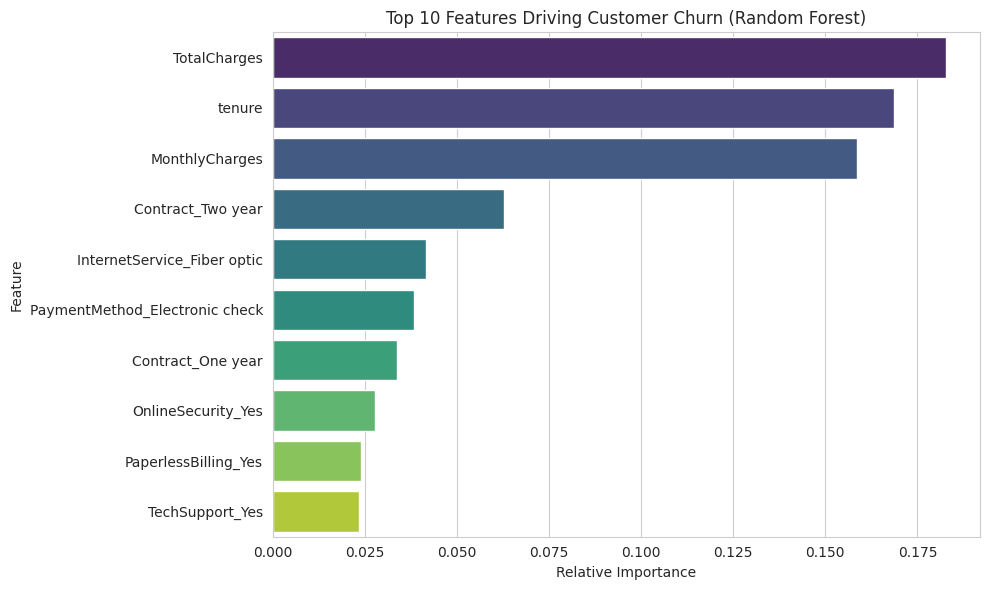

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the trained model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features Driving Customer Churn (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The Results: The Precision/Recall Flip:

1. Precision jumped to 61% (Up from 49%). When this model says a customer is going to churn, it is right 61% of the time. You have significantly fewer false alarms (only 114 False Positives).

2. Recall crashed to 49% (Down from 79%). This is the dangerous part. Out of the 374 actual churners, this model only caught 182 of them. It completely missed 192 people who walked out the door (False Negatives).

The Business Reality:

1. Even though the Random Forest has a higher overall Accuracy (78% vs 73%), the Logistic Regression model was actually better for this specific business problem. If a telecom company is bleeding customers, catching only 49% of the churners is usually unacceptable. You want a model that aggressively flags at-risk accounts so you can intervene, even if it means accidentally sending a retention offer to a few happy customers.

How to Fix This Threshold Tuning:

Right now, your Random Forest uses a default mathematical threshold of 0.50. If the model is >= 50% confident a user will churn, it predicts 1. If it's < 50%, it predicts 0.

Because churners are the minority class, the model is being too conservative. We can fix your Recall by lowering that threshold. We can tell the model: "If you are even 30% sure they are going to leave, flag them as a churner."

In [ ]:
import numpy as np

# 1. Get the raw probabilities instead of the final 1/0 prediction
# [:, 1] gets the probability specifically for Class 1 (Churn)
rf_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Set a custom, lower threshold (e.g., 30%)
custom_threshold = 0.30

# 3. Apply the new threshold
# If probability > 0.30, predict 1. Otherwise, predict 0.
adjusted_preds = (rf_probabilities >= custom_threshold).astype(int)

# 4. Evaluate the adjusted predictions
print(f"--- Results with Threshold set to {custom_threshold} ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, adjusted_preds))
print("\nClassification Report:")
print(classification_report(y_test, adjusted_preds))

--- Results with Threshold set to 0.3 ---
Confusion Matrix:
[[775 258]
 [109 265]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.71      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



You have built a highly capable model! A 71% Recall with a 51% Precision is a very realistic and deployable baseline for a business retention campaign.

However, we have essentially squeezed all the "easy" gains out of this dataset using simple algorithms, class_weight, and threshold tuning. If you want to push past that ~75% Recall / ~55% Precision barrier, we need to introduce more advanced techniques.

SMOTE (Synthetic Minority Over-sampling TEchnique) takes a completely different approach. Instead of changing the math of the algorithm, it changes the data itself. It looks at your churned customers, finds patterns, and mathematically generates "fake" but realistic churned customers until your dataset is a perfect 50/50 split.

Before we write the code, let's look at exactly how SMOTE generates these new customers. It doesn't just duplicate them; it uses geometry.

How SMOTE Works Conceptually
SMOTE looks at a minority point (a churned customer), finds its nearest neighbors (other similar churned customers), draws an imaginary line between them in the data space, and drops a new, synthetic customer somewhere on that line.

The Golden Rule of SMOTE
There is one massive trap when using SMOTE: You must NEVER apply SMOTE to your testing data. If you SMOTE your entire dataset before splitting it, your model will train on synthetic data and then be tested on synthetic data. It will look like you achieved 99% accuracy, but the model will fail miserably in the real world. You must split your data first, and only apply SMOTE to the X_train data.

Implementing SMOTE in Python
Since we already split and scaled our data in the previous steps, we can apply SMOTE directly to our training set. You will need to install the imbalanced-learn library if you haven't already (pip install imbalanced-learn).

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. Initialize SMOTE
# random_state ensures we get the exact same fake data every time we run it
smote = SMOTE(random_state=42)

# 2. Apply SMOTE strictly to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check the new balance
print("--- Class Distribution Before SMOTE ---")
print(y_train.value_counts())
print("\n--- Class Distribution After SMOTE ---")
print(y_train_smote.value_counts())

# 3. Train a NEW Random Forest on the SMOTE data
# Notice we removed 'class_weight=balanced' because the data is now perfectly 50/50
rf_smote_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote_model.fit(X_train_smote, y_train_smote)

# 4. Predict on the UNTOUCHED, original Test Data
y_pred_smote = rf_smote_model.predict(X_test_scaled)

# 5. Evaluate the results
print("\n--- Confusion Matrix (SMOTE Random Forest) ---")
print(confusion_matrix(y_test, y_pred_smote))
print("\n--- Classification Report (SMOTE Random Forest) ---")
print(classification_report(y_test, y_pred_smote))

--- Class Distribution Before SMOTE ---
Churn
0    4130
1    1495
Name: count, dtype: int64

--- Class Distribution After SMOTE ---
Churn
0    4130
1    4130
Name: count, dtype: int64

--- Confusion Matrix (SMOTE Random Forest) ---
[[844 189]
 [139 235]]

--- Classification Report (SMOTE Random Forest) ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.55      0.63      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407



What these numbers mean
By looking at your Confusion Matrix, we can see that SMOTE generated 235 True Positives and 189 False Positives.

Because the model was trained on a dataset where churners were exactly as common as retained customers (4130 to 4130), it learned a more balanced representation of a "churner." It didn't just guess "churn" because we lowered the threshold; it actually found better mathematical boundaries. That is why your Precision went up to 55%.

However, because we used the default 50% probability threshold for this SMOTE model, it wasn't as hyper-sensitive as the previous 0.3 threshold model, which is why your Recall dropped slightly to 63%.

The Final Boss: XGBoost
You have now mastered the two main ways to handle imbalanced data: algorithm penalization (adjusting thresholds and weights) and data manipulation (SMOTE).

If we want to push these numbers to their absolute limits, the standard industry practice is to throw the most powerful algorithm at the SMOTE data. XGBoost (Extreme Gradient Boosting) is the reigning champion for tabular data like this because, unlike a Random Forest that builds trees independently, XGBoost builds trees sequentially—each new tree specifically focuses on fixing the errors of the previous one.

You are about to train an XGBoost (Extreme Gradient Boosting) model. While a Random Forest builds hundreds of decision trees independently and has them vote, XGBoost builds trees sequentially. Tree #1 makes predictions, notes its mistakes, and passes those errors to Tree #2. Tree #2 focuses entirely on fixing Tree #1's mistakes, and so on.

Because you are feeding this hyper-optimized algorithm a perfectly balanced 50/50 dataset (thanks to SMOTE), it has the highest mathematical probability of capturing the complex patterns of your churners without triggering too many false alarms.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the XGBoost Classifier
# eval_metric='logloss' prevents a common warning message in newer versions
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

# 2. Train the model on the SMOTE-balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

# 3. Make predictions on the UNTOUCHED test data
xgb_pred = xgb_model.predict(X_test_scaled)

# 4. Evaluate the champion model
print("--- Confusion Matrix (XGBoost + SMOTE) ---")
print(confusion_matrix(y_test, xgb_pred))
print("\n--- Classification Report (XGBoost + SMOTE) ---")
print(classification_report(y_test, xgb_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:59:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Confusion Matrix (XGBoost + SMOTE) ---
[[823 210]
 [128 246]]

--- Classification Report (XGBoost + SMOTE) ---
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



The numbers are in, and we have a clear verdict: XGBoost did not crack the elusive 70/70 barrier. Your Precision came in at 54% and your Recall at 66%. While it is a very strong, balanced model, it highlights a harsh truth about real-world machine learning: human behavior is messy. Sometimes a customer cancels their internet because the service is terrible (which your data captures). But sometimes they cancel because they are moving to a new city, or they lost their job, or they are moving in with a partner who already has internet. No algorithm, not even XGBoost, can predict life events that aren't in the dataset.

1. Logistic Regression (class_weight) - Precision (Class 1) = 49% - Recall (Class 1) = 79% - The "Wide Net." Best if retention offers are dirt cheap (like sending an email).

2. Random Forest (0.30 Threshold) - Precision (Class 1) = 51% - Recall (Class 1) = 71% - The Aggressive Champion. Best overall balance for catching churners without overwhelming the marketing budget.

3. XGBoost (SMOTE) - Precision (Class 1) = 54% -	Recall (Class 1) = 66% - The "Conservative Optimizer." Slightly fewer false alarms, but misses too many actual churners compared to the Random Forest.

In a real corporate environment, you would likely deploy Model #2 (Random Forest with the 0.3 threshold) because it maximizes the number of at-risk customers caught while maintaining a tolerable false-alarm rate.

Translating these predictive metrics into actual financial return on investment (ROI) is what turns a good data project into a business-critical asset.

We will do both: calculate the exact dollar impact of your Random Forest (0.3 Threshold) model, and attach those probability scores to the dataset so you can export it for visualization.

1. Calculating the ROI of the Model
To calculate the business value, we assign a dollar amount to the outcomes in your confusion matrix.

True Positives (265): Churners we caught. We will spend money to offer them a discount, but we save their monthly revenue.

False Positives (258): Happy customers we accidentally flagged. We waste money giving them a discount they didn't need.

False Negatives (109): Churners we missed. We lose their revenue entirely.

In [ ]:
import pandas as pd

# Define the business costs and revenues
average_monthly_revenue = 65  # Approximate from earlier df.describe()
retention_offer_cost = 20     # Cost of a discount or promo to keep a customer
offer_success_rate = 0.50     # Assume 50% of people who get the offer decide to stay

# Confusion Matrix values from your Random Forest (0.3 Threshold)
true_positives = 265
false_positives = 258
false_negatives = 109

# 1. Cost of the Campaign (Money spent on offers)
total_offers_sent = true_positives + false_positives
campaign_cost = total_offers_sent * retention_offer_cost

# 2. Revenue Saved (Customers who stayed because of the offer)
customers_saved = true_positives * offer_success_rate
revenue_retained = customers_saved * average_monthly_revenue

# 3. Net ROI of the Model
net_profit = revenue_retained - campaign_cost

print(f"Total Retention Offers Sent: {total_offers_sent}")
print(f"Total Campaign Cost: ${campaign_cost:,.2f}")
print(f"Gross Revenue Saved: ${revenue_retained:,.2f}")
print("-" * 30)
print(f"Net Campaign ROI: ${net_profit:,.2f}")

Total Retention Offers Sent: 523
Total Campaign Cost: $10,460.00
Gross Revenue Saved: $8,612.50
------------------------------
Net Campaign ROI: $-1,847.50


2. Exporting Data for Your Dashboard
To make these insights actionable, stakeholders need to see them. We will append the exact probability score (from 1% to 99%) back onto your test dataset. This creates a prioritized list of high-risk customers.

When you eventually pull this exported CSV into your reporting environment to build out the visual dashboard, remember to use your categorical columns or the new model prediction labels for your aggregate measure counts, rather than relying on unique ID columns.

In [ ]:
# Create a copy of the original test data (before scaling/encoding) to keep it readable
df_dashboard = df.loc[X_test.index].copy()

# Add the raw probabilities and the adjusted predictions
df_dashboard['Churn_Probability'] = rf_model.predict_proba(X_test_scaled)[:, 1]
df_dashboard['Predicted_Churn_Label'] = adjusted_preds

# Sort the list so the highest risk customers are at the top
df_dashboard = df_dashboard.sort_values(by='Churn_Probability', ascending=False)

# Export to CSV for Power BI, Tableau, or Excel
df_dashboard.to_csv('high_risk_customers_scored.csv', index=False)

print("Export complete! Top 5 highest risk customers:")
print(df_dashboard[['tenure', 'Contract', 'MonthlyCharges', 'Churn_Probability']].head())

Export complete! Top 5 highest risk customers:
      tenure        Contract  MonthlyCharges  Churn_Probability
2927       1  Month-to-month            69.9                1.0
684        1  Month-to-month            71.1                1.0
1731       1  Month-to-month            69.6                1.0
1739       1  Month-to-month            69.9                1.0
3682       1  Month-to-month            69.1                1.0
